<a href="https://colab.research.google.com/github/gaurizendekar/Data_Science_labs/blob/main/Exp2_Backpropagation_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment 2: Backpropagation using TensorFlow

Aim:To understand and implement backpropagation using TensorFlow.

tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor(5, shape=(), dtype=int32)
tf.Tensor(
[[0. 1.]
 [2. 3.]], shape=(2, 2), dtype=float32)
[[0. 1.]
 [2. 3.]]
<tf.Variable 'Variable:0' shape=(2,) dtype=float32, numpy=array([1., 2.], dtype=float32)>
tf.Tensor(
[[1.]
 [2.]], shape=(2, 1), dtype=float32)
tf.Tensor(
[[2.]
 [8.]], shape=(2, 1), dtype=float32)


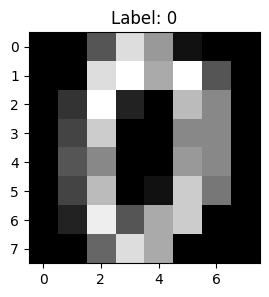

Epoch 1, Loss: 2.4211, Accuracy: 0.0585
Epoch 2, Loss: 2.3327, Accuracy: 0.0745
Epoch 3, Loss: 2.2492, Accuracy: 0.1023
Epoch 4, Loss: 2.1705, Accuracy: 0.1482
Epoch 5, Loss: 2.0961, Accuracy: 0.2088
Epoch 6, Loss: 2.0255, Accuracy: 0.2644
Epoch 7, Loss: 1.9587, Accuracy: 0.3312
Epoch 8, Loss: 1.8952, Accuracy: 0.3918
Epoch 9, Loss: 1.8350, Accuracy: 0.4572
Epoch 10, Loss: 1.7772, Accuracy: 0.5003
Epoch 11, Loss: 1.7216, Accuracy: 0.5456
Epoch 12, Loss: 1.6677, Accuracy: 0.5672
Epoch 13, Loss: 1.6150, Accuracy: 0.6019
Epoch 14, Loss: 1.5637, Accuracy: 0.6249
Epoch 15, Loss: 1.5133, Accuracy: 0.6465
Epoch 16, Loss: 1.4638, Accuracy: 0.6688
Epoch 17, Loss: 1.4150, Accuracy: 0.6875
Epoch 18, Loss: 1.3667, Accuracy: 0.7119
Epoch 19, Loss: 1.3190, Accuracy: 0.7328
Epoch 20, Loss: 1.2718, Accuracy: 0.7474

Test Accuracy: 0.75


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# TensorFlow Constants and Variables

a = tf.constant(3)
print(a)

b = tf.constant(2)
c = a + b
print(c)

# Matrix Operations
A = tf.constant([[0, 1], [2, 3]], dtype=tf.float32)
print(A)

print(A.numpy())

b = tf.Variable([1, 2], dtype=tf.float32)
print(b)

reshaped_b = tf.reshape(b, (-1, 1))
print(reshaped_b)

matmul_result = tf.matmul(A, reshaped_b)
print(matmul_result)

# Load Dataset

digits = load_digits()

X = digits.data
y = digits.target

# Show Sample Image
plt.figure(figsize=(3,3))
plt.imshow(digits.images[0], cmap='gray')
plt.title(f"Label: {digits.target[0]}")
plt.show()

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One Hot Encoding
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Convert to TensorFlow tensors
X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
Y_train = tf.convert_to_tensor(Y_train, dtype=tf.float32)
Y_test = tf.convert_to_tensor(Y_test, dtype=tf.float32)

# Define Variables for Neural Network
initializer = tf.initializers.GlorotUniform()

W1 = tf.Variable(initializer(shape=(64, 100)))
b1 = tf.Variable(tf.zeros([100]))

W2 = tf.Variable(initializer(shape=(100, 50)))
b2 = tf.Variable(tf.zeros([50]))

W3 = tf.Variable(initializer(shape=(50, 10)))
b3 = tf.Variable(tf.zeros([10]))

# Forward Pass Function

def neural_network(x):
    z1 = tf.matmul(x, W1) + b1
    a1 = tf.nn.relu(z1)

    z2 = tf.matmul(a1, W2) + b2
    a2 = tf.nn.relu(z2)

    z3 = tf.matmul(a2, W3) + b3

    return z3

# Loss Function

def compute_loss(logits, labels):
    loss = tf.reduce_mean(
        tf.nn.softmax_cross_entropy_with_logits(
            labels=labels,
            logits=logits
        )
    )
    return loss

# Optimizer
optimizer = tf.optimizers.Adam(learning_rate=0.001)

# Training Loop
epochs = 20

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        logits = neural_network(X_train)
        loss = compute_loss(logits, Y_train)

    gradients = tape.gradient(
        loss,
        [W1, b1, W2, b2, W3, b3]
    )

    optimizer.apply_gradients(
        zip(gradients, [W1, b1, W2, b2, W3, b3])
    )

    predictions = tf.argmax(logits, axis=1)
    actual = tf.argmax(Y_train, axis=1)

    accuracy = tf.reduce_mean(
        tf.cast(predictions == actual, tf.float32)
    )

    print(
        f"Epoch {epoch+1}, Loss: {loss.numpy():.4f}, Accuracy: {accuracy.numpy():.4f}"
    )

# Testing

test_logits = neural_network(X_test)

test_predictions = tf.argmax(test_logits, axis=1)
test_actual = tf.argmax(Y_test, axis=1)

test_accuracy = tf.reduce_mean(
    tf.cast(test_predictions == test_actual, tf.float32)
)

print("\nTest Accuracy:", test_accuracy.numpy())


Conclusion: Successfully implemented backpropagation using TensorFlow and trained a multilayer neural network for digit classification.
